# 08 · 타부 서치(TS) 최적화 — GA·SA와의 3방향 비교

개요 v3 §2 **A→C 확장의 3단계(완결)**. 06(GA)·07(SA)에서 푼 것과 **완전히 같은 문제**를
Tabu Search로 다시 풀어, 세 메타휴리스틱을 비교한다.

## 왜 하는가

**세 개의 독립적인 방법이 같은 답에 도달하면**, 그 답은 특정 알고리즘의 산물이 아니라
**문제 구조의 산물**이다. 06의 재배치 결론(면적 11.2% 전환 → 손실 16.0% 회복)이
얼마나 믿을 만한지를 최종 검증한다.

## 06/07과 무엇이 같은가

| | 06 (GA) | 07 (SA) | 08 (TS) |
|---|---|---|---|
| 문제 | 2,142 카운티 단작 배분 | 동일 | **동일** |
| 목적함수 | Σ A_c·v[c,z_c] − λ·전환면적 | 동일 | **동일** |
| 예측값·A_c·x̄ | 06 산출 | 06 산출 | **06 산출 그대로** |
| 탐색 | 개체군·교차·돌연변이 | 단일해·확률적 수용 | 단일해·**결정적 최선이동 + 타부** |

문제 정의는 `CropAllocationProblem`(`src/optimize_ga.py`)을 **재사용**한다 —
"같은 문제를 풀었다"가 코드 수준에서 보장된다.

> 06·07의 원본과 산출물은 **건드리지 않는다.** 이 노트북은 읽기만 한다.

In [1]:
import sys, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))

from optimize_ga import (CropAllocationProblem, run_ga, greedy,
                         make_min_demand_constraint, find_knee)
from optimize_sa import run_sa
from optimize_ts import run_ts, sweep_lambda_ts

RAW  = Path('..') / 'data' / 'raw'          # 읽기 전용
PROC = Path('..') / 'data' / 'processed'
FIG  = Path('..') / 'outputs' / 'figures'
RES  = Path('..') / 'outputs' / 'results'

SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = '#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948'
CORN_C, SOY_C = '#eda100', '#1baf7a'
GA_C, SA_C, TS_C, EX_C = BLUE, RED, GREEN, MUTED     # GA=파랑 SA=빨강 TS=초록 정확해=회색

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'semibold',
    'axes.labelsize': 10.5, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

SEED = 42
print('모듈 로드 — optimize_ga, optimize_sa, optimize_ts')

모듈 로드 — optimize_ga, optimize_sa, optimize_ts


## 1. 06의 문제를 그대로 복원

In [2]:
d    = pd.read_parquet(PROC / 'optimization_results.parquet')
meta = json.load(open(PROC / 'optimization_columns.json', encoding='utf-8'))

COUNTIES = d['stco'].to_numpy()
A        = d['A_c'].to_numpy(float)
XBAR     = d['x_bar'].to_numpy(np.int8)
N, A_TOT = len(d), A.sum()

prob      = CropAllocationProblem(np.column_stack([d['v_corn_warm'], d['v_soy_warm']]), A, XBAR)
prob_base = CropAllocationProblem(np.column_stack([d['v_corn_base'], d['v_soy_base']]), A, XBAR)

V_BASE_NOADAPT = prob_base.total_value(XBAR)
V_WARM_NOADAPT = prob.total_value(XBAR)
LOSS = V_BASE_NOADAPT - V_WARM_NOADAPT
KNEE_LAM = float(meta['lambda_knee'])

Z_EXACT = prob.exact_optimum(KNEE_LAM)
F_EXACT = prob.fitness(Z_EXACT, KNEE_LAM)
assert (Z_EXACT == d['z_exact_knee'].to_numpy()).all(), '정확해가 06과 다르다'

print('카운티 N = %d · 총 농지 %.3e ac' % (N, A_TOT))
print('온난화 손실 $%.4e (%.1f%%)' % (LOSS, 100 * LOSS / V_BASE_NOADAPT))
print('무릎 λ = %.4f $/ac' % KNEE_LAM)
print('\n정합성: 06의 정확해를 비트 단위로 재현 → OK')
print('정확해 F* = $%.6e   (세 방법을 채점할 기준)' % F_EXACT)
print('정확해에 도달하려면 현재 배분에서 %d개 카운티를 뒤집어야 한다.' % prob.n_switched(Z_EXACT))

카운티 N = 2142 · 총 농지 1.583e+09 ac
온난화 손실 $8.5743e+10 (22.3%)
무릎 λ = 42.2949 $/ac

정합성: 06의 정확해를 비트 단위로 재현 → OK
정확해 F* = $3.056875e+11   (세 방법을 채점할 기준)
정확해에 도달하려면 현재 배분에서 238개 카운티를 뒤집어야 한다.


## 2. TS 설계 — 그리고 "평가 예산"의 함정

- **상태**: 길이 2,142 이진 벡터 (GA 염색체·SA 상태와 같은 표현)
- **이웃**: 카운티 하나의 작물 뒤집기(1-flip)
- **이동**: **최선 이동(best improvement)** — 이웃 중 가장 좋은 곳으로 간다.
  개선 이동이 없어도 **반드시 이동한다**(가장 덜 나쁜 곳으로). 이것이 TS의 탈출 방식이다.
- **타부**: 방금 뒤집은 카운티를 `tabu_tenure`회 동안 재금지 → **순환(cycling) 방지**
- **열망(aspiration)**: 타부여도 역대 최고 해를 갱신하면 허용

### ⚠ 공정 비교의 함정 — TS는 한 번 이동할 때마다 이웃 전체를 평가한다

GA·SA는 한 번의 "평가"가 해 하나를 보는 것이다. 그런데 TS는 **한 번 이동하려고 이웃 N개를
모두 평가**한다. 이웃 전체(2,142개)를 쓰면 GA·SA와 같은 예산(160,200 평가)에서
겨우 **74번**밖에 이동하지 못한다. 그런데 최적해까지는 **238개**를 뒤집어야 한다 → **예산 부족.**

그래서 두 가지 모드를 모두 돌려 정직하게 비교한다:

| 모드 | 이웃 | 반복 | 평가 횟수 |
|---|---|---|---|
| **TS (정석)** | 전체 2,142개 | 1,000 | 2,142,000 (예산의 13배) |
| **TS (예산 맞춤)** | 후보 500개 무작위 | 320 | 160,000 (GA·SA와 동일) |

후보 리스트(candidate list)는 큰 이웃을 가진 문제에서 쓰는 TS의 표준 기법이다.

> **핵심 반전.** "평가 횟수"로 보면 TS가 불리해 보이지만, 이 문제에서는 이웃 전체의 ΔF를
> **numpy 벡터 연산 한 방**에 구할 수 있다(목적함수가 분리 가능하므로). 그래서 평가 2백만 회가
> 벽시계로는 **0.1초도 안 걸린다.** §5에서 이 반전을 확인한다.

In [3]:
GA_POP, GA_GEN = 200, 800
BUDGET = GA_POP * (GA_GEN + 1)                # 160,200 — GA·SA가 쓴 평가 예산
SA_LEVELS, SA_ALPHA = 200, 0.95

TS_TENURE   = 20
TS_ITER     = 1000                            # 정석: 이웃 전체
TS_CAND_K   = 500                             # 예산 맞춤: 후보 리스트
TS_CAND_ITER = BUDGET // TS_CAND_K            # 320

print('평가 예산 (GA·SA 기준): {:,}'.format(BUDGET))
print('TS 타부 기간(tenure) = %d' % TS_TENURE)
print('TS 정석      : 이웃 전체 {:,}개 × {:,} 반복 = {:,} 평가'
      .format(N, TS_ITER, N * TS_ITER))
print('TS 예산 맞춤 : 후보 {:,}개 × {:,} 반복 = {:,} 평가'
      .format(TS_CAND_K, TS_CAND_ITER, TS_CAND_K * TS_CAND_ITER))

평가 예산 (GA·SA 기준): 160,200
TS 타부 기간(tenure) = 20
TS 정석      : 이웃 전체 2,142개 × 1,000 반복 = 2,142,000 평가
TS 예산 맞춤 : 후보 500개 × 320 반복 = 160,000 평가


### 2-1. 세 방법 단일 실행 (λ = 무릎)

In [4]:
ga    = run_ga(prob, KNEE_LAM, pop_size=GA_POP, n_generations=GA_GEN, seed=SEED)
sa    = run_sa(prob, KNEE_LAM, n_iter=BUDGET, n_temp_levels=SA_LEVELS,
               alpha=SA_ALPHA, target_accept=0.8, seed=SEED)
ts    = run_ts(prob, KNEE_LAM, n_iter=TS_ITER, n_candidates=None,
               tabu_tenure=TS_TENURE, seed=SEED)
ts_b  = run_ts(prob, KNEE_LAM, n_iter=TS_CAND_ITER, n_candidates=TS_CAND_K,
               tabu_tenure=TS_TENURE, seed=SEED)

RUNS = [('GA', ga), ('SA', sa), ('TS (정석)', ts), ('TS (예산 맞춤)', ts_b)]
rows = []
for nm, r in RUNS:
    rows.append(dict(방법=nm, 적합도=r['best_fit'],
                     갭_pct=100 * (F_EXACT - r['best_fit']) / abs(F_EXACT),
                     정확해일치_pct=100 * (r['best'] == Z_EXACT).mean(),
                     평가횟수=r['n_eval'], 초=r['seconds']))
single = pd.DataFrame(rows)
print('세 방법 단일 실행 (λ = %.0f)' % KNEE_LAM)
print(single.to_string(index=False, float_format='%.6g'))

print()
print('TS 탐색 통계 (정석 모드)')
print('  이동 횟수          {:,}'.format(ts['n_iter']))
print('  나빠지는데도 감행한 이동 {:,}  ← 개선 이동이 없을 때의 탈출'.format(ts['n_uphill']))
print('  타부에 막힌 후보    {:,}  ← 순환 방지가 실제로 작동'.format(ts['n_tabu_blocked']))
print('  열망으로 타부 해제  {:,}'.format(ts['n_aspiration']))

세 방법 단일 실행 (λ = 42)
        방법         적합도       갭_pct  정확해일치_pct    평가횟수         초
        GA 3.05687e+11           0        100  160200    10.764
        SA 3.05687e+11           0        100  160200   7.96181
   TS (정석) 3.05687e+11           0        100 2142000  0.240365
TS (예산 맞춤) 3.05687e+11 2.02136e-05    99.9066  160000 0.0560752

TS 탐색 통계 (정석 모드)
  이동 횟수          1,000
  나빠지는데도 감행한 이동 384  ← 개선 이동이 없을 때의 탈출
  타부에 막힌 후보    19,790  ← 순환 방지가 실제로 작동
  열망으로 타부 해제  0


### 그림 1 — GA vs SA vs TS 수렴 곡선

saved: ..\outputs\figures\fig35_three_way_convergence.png


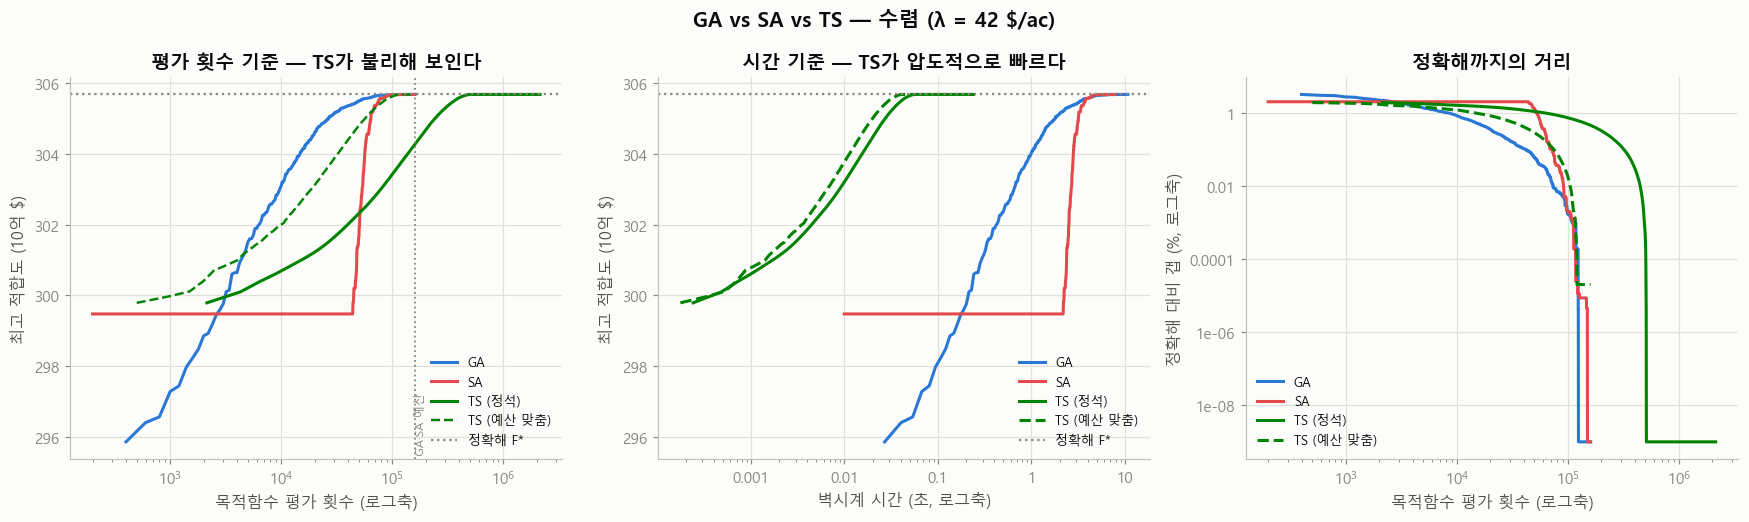

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ga_evals = np.arange(1, GA_GEN + 1) * GA_POP + GA_POP

# (a) 평가 횟수 축 — TS(정석)는 예산을 훨씬 많이 쓴다
ax = axes[0]
ax.plot(ga_evals, ga['history'] / 1e9, color=GA_C, lw=2, label='GA')
ax.plot(sa['hist_evals'], sa['history'] / 1e9, color=SA_C, lw=2, label='SA')
ax.plot(ts['hist_evals'], ts['history'] / 1e9, color=TS_C, lw=2, label='TS (정석)')
ax.plot(ts_b['hist_evals'], ts_b['history'] / 1e9, color=TS_C, lw=1.6, ls='--',
        label='TS (예산 맞춤)')
ax.axvline(BUDGET, color=MUTED, ls=':', lw=1.2)
ax.text(BUDGET, ax.get_ylim()[0], ' GA·SA 예산', fontsize=8, color=MUTED, rotation=90,
        va='bottom')
ax.axhline(F_EXACT / 1e9, color=EX_C, ls=':', lw=1.5, label='정확해 F*')
ax.set_xscale('log')
ax.set_xlabel('목적함수 평가 횟수 (로그축)')
ax.set_ylabel('최고 적합도 (10억 $)')
ax.set_title('평가 횟수 기준 — TS가 불리해 보인다')
ax.legend(frameon=False, fontsize=8.5, loc='lower right')

# (b) 벽시계 시간 축 — 반전
ax = axes[1]
# GA 는 hist_evals 를 반환하지 않으므로 세대→평가 환산치를 쓴다
for nm, r, ev, col, ls in [('GA', ga, ga_evals, GA_C, '-'),
                           ('SA', sa, sa['hist_evals'], SA_C, '-'),
                           ('TS (정석)', ts, ts['hist_evals'], TS_C, '-'),
                           ('TS (예산 맞춤)', ts_b, ts_b['hist_evals'], TS_C, '--')]:
    frac = ev / r['n_eval']                       # 진행률 → 벽시계 시간으로 환산
    ax.plot(frac * r['seconds'], r['history'] / 1e9, color=col, ls=ls, lw=2, label=nm)
ax.axhline(F_EXACT / 1e9, color=EX_C, ls=':', lw=1.5, label='정확해 F*')
ax.set_xscale('log')
# 음수 지수(10^-3 등)의 마이너스가 mathtext 로 렌더되며 깨지므로 ASCII 라벨로 강제
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: '%g' % v))
ax.set_xlabel('벽시계 시간 (초, 로그축)')
ax.set_ylabel('최고 적합도 (10억 $)')
ax.set_title('시간 기준 — TS가 압도적으로 빠르다')
ax.legend(frameon=False, fontsize=8.5, loc='lower right')

# (c) 갭 (로그축)
ax = axes[2]
for nm, ev, hist, col, ls in [
        ('GA', ga_evals, ga['history'], GA_C, '-'),
        ('SA', sa['hist_evals'], sa['history'], SA_C, '-'),
        ('TS (정석)', ts['hist_evals'], ts['history'], TS_C, '-'),
        ('TS (예산 맞춤)', ts_b['hist_evals'], ts_b['history'], TS_C, '--')]:
    gap = 100 * (F_EXACT - hist) / abs(F_EXACT)
    ax.plot(ev, np.maximum(gap, 1e-9), color=col, ls=ls, lw=2, label=nm)
ax.set_xscale('log'); ax.set_yscale('log')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: '%g' % v))
ax.set_xlabel('목적함수 평가 횟수 (로그축)')
ax.set_ylabel('정확해 대비 갭 (%, 로그축)')
ax.set_title('정확해까지의 거리')
ax.legend(frameon=False, fontsize=8.5)

fig.suptitle('GA vs SA vs TS — 수렴 (λ = %.0f $/ac)' % KNEE_LAM,
             fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig35_three_way_convergence.png'); plt.show()

## 3. 안정성 — 10개 seed 반복

메타휴리스틱 비교의 공정성은 반복 실행에 달려 있다(개요 §9).
같은 조건에서 seed만 바꿔 10회씩 돌려 평균±표준편차를 본다.

In [6]:
N_SEEDS = 10
METHODS = {
    'GA':            lambda s: run_ga(prob, KNEE_LAM, pop_size=GA_POP, n_generations=GA_GEN, seed=s),
    'SA':            lambda s: run_sa(prob, KNEE_LAM, n_iter=BUDGET, n_temp_levels=SA_LEVELS,
                                      alpha=SA_ALPHA, target_accept=0.8, seed=s),
    'TS (정석)':      lambda s: run_ts(prob, KNEE_LAM, n_iter=TS_ITER, n_candidates=None,
                                      tabu_tenure=TS_TENURE, seed=s),
    'TS (예산 맞춤)':  lambda s: run_ts(prob, KNEE_LAM, n_iter=TS_CAND_ITER,
                                      n_candidates=TS_CAND_K, tabu_tenure=TS_TENURE, seed=s),
}

rows = []
for nm, fn in METHODS.items():
    for s in range(N_SEEDS):
        r = fn(s)
        rows.append(dict(method=nm, seed=s, fitness=r['best_fit'],
                         gap_pct=100 * (F_EXACT - r['best_fit']) / abs(F_EXACT),
                         agree_pct=100 * (r['best'] == Z_EXACT).mean(),
                         n_switch=prob.n_switched(r['best']),
                         recovery_pct=prob.recovery_pct(r['best'], V_WARM_NOADAPT, LOSS),
                         seconds=r['seconds'], n_eval=r['n_eval']))
stab = pd.DataFrame(rows)
stab.to_csv(RES / 'ts_three_way_stability.csv', index=False)

summ = stab.groupby('method', sort=False).agg(
    갭평균_pct=('gap_pct', 'mean'), 갭최악_pct=('gap_pct', 'max'),
    적합도_표준편차=('fitness', 'std'),
    정확해일치_pct=('agree_pct', 'mean'),
    전환카운티_평균=('n_switch', 'mean'), 전환카운티_표준편차=('n_switch', 'std'),
    회복률_평균=('recovery_pct', 'mean'), 회복률_표준편차=('recovery_pct', 'std'),
    시간_평균초=('seconds', 'mean'), 평가횟수=('n_eval', 'mean'),
).reset_index()

print('GA vs SA vs TS — %d개 seed 반복 (λ = %.0f)' % (N_SEEDS, KNEE_LAM))
print(summ.to_string(index=False, float_format='%.4g'))
print('\nsaved:', RES / 'ts_three_way_stability.csv')
print('\n정확해 F* = $%.6e' % F_EXACT)

GA vs SA vs TS — 10개 seed 반복 (λ = 42)
    method   갭평균_pct   갭최악_pct  적합도_표준편차  정확해일치_pct  전환카운티_평균  전환카운티_표준편차  회복률_평균  회복률_표준편차  시간_평균초      평가횟수
        GA         0         0         0        100       238           0   15.99         0   16.43 1.602e+05
        SA         0         0         0        100       238           0   15.99         0    5.06 1.602e+05
   TS (정석)         0         0         0        100       238           0   15.99         0  0.1347 2.142e+06
TS (예산 맞춤) 6.836e-05 0.0002923  2.86e+05       99.9     239.2        2.15   16.04   0.05612 0.02951   1.6e+05

saved: ..\outputs\results\ts_three_way_stability.csv

정확해 F* = $3.056875e+11


## 4. 트레이드오프 곡선 — 세 방법 겹치기

06이 저장한 λ 스윕(GA·정확해)을 읽고, 07의 SA 결과를 읽고, 같은 λ 격자에서 TS를 돌린다.

In [7]:
sw06 = pd.read_csv(RES / 'lambda_sweep_tradeoff.csv')    # 06 산출 (읽기만)
sw07 = pd.read_csv(RES / 'sa_tradeoff.csv')              # 07 산출 (읽기만)
LAMBDAS = np.sort(sw06['lambda'].unique())
print('λ 격자 %d개 재사용' % len(LAMBDAS))

ts_rows = sweep_lambda_ts(prob, LAMBDAS, V_WARM_NOADAPT, LOSS,
                          n_iter=TS_ITER, n_candidates=None,
                          tabu_tenure=TS_TENURE, seed=SEED)
sw_ts = pd.DataFrame(ts_rows).sort_values('pct_area').reset_index(drop=True)
sw_ts.to_csv(RES / 'ts_tradeoff.csv', index=False)
print('saved:', RES / 'ts_tradeoff.csv')

sw_ga = sw06[sw06.method == 'GA'].sort_values('pct_area').reset_index(drop=True)
sw_ex = sw06[sw06.method == 'exact'].sort_values('pct_area').reset_index(drop=True)
sw_sa = sw07.sort_values('pct_area').reset_index(drop=True)

cmp = (sw_ex[['lambda', 'recovery_pct']].rename(columns={'recovery_pct': 'exact'})
       .merge(sw_ga[['lambda', 'recovery_pct']].rename(columns={'recovery_pct': 'GA'}), on='lambda')
       .merge(sw_sa[['lam', 'recovery_pct']].rename(columns={'lam': 'lambda', 'recovery_pct': 'SA'}), on='lambda')
       .merge(sw_ts[['lam', 'recovery_pct']].rename(columns={'lam': 'lambda', 'recovery_pct': 'TS'}), on='lambda'))
for m in ['GA', 'SA', 'TS']:
    cmp[m + '−exact'] = cmp[m] - cmp['exact']

print('\nλ별 회복률(%) — 정확해 대비 편차')
print(cmp.round(4).to_string(index=False))
print('\n최대 |편차|:  GA %.4f%%p · SA %.4f%%p · TS %.4f%%p'
      % (cmp['GA−exact'].abs().max(), cmp['SA−exact'].abs().max(), cmp['TS−exact'].abs().max()))

λ 격자 18개 재사용


saved: ..\outputs\results\ts_tradeoff.csv

λ별 회복률(%) — 정확해 대비 편차
  lambda   exact      GA      SA      TS  GA−exact  SA−exact  TS−exact
400.0000  0.0000  0.0000  0.0000  0.0000    0.0000     0.000       0.0
275.0624  0.0000  0.0000  0.0000  0.0000    0.0000     0.000       0.0
189.1483  0.5487  0.5487  0.5487  0.5487    0.0000     0.000       0.0
130.0690  2.9253  2.9253  2.9253  2.9253    0.0000     0.000       0.0
 89.4427  6.1896  6.1896  6.1896  6.1896    0.0000     0.000       0.0
 61.5058 12.4388 12.4388 12.4328 12.4388    0.0000    -0.006       0.0
 42.2949 15.9882 15.9882 15.9882 15.9882    0.0000     0.000       0.0
 29.0843 18.9440 18.9440 18.9440 18.9440    0.0000     0.000       0.0
 20.0000 20.7031 20.7031 20.7031 20.7031    0.0000     0.000       0.0
 13.7531 21.6315 21.6133 21.6315 21.6315   -0.0182     0.000       0.0
  9.4574 22.1116 22.1172 22.1116 22.1116    0.0056     0.000      -0.0
  6.5034 22.3936 22.3822 22.3936 22.3936   -0.0114     0.000       0.0
  4.4721 22.

### 그림 2 — 세 방법 트레이드오프 곡선

saved: ..\outputs\figures\fig36_three_way_tradeoff.png


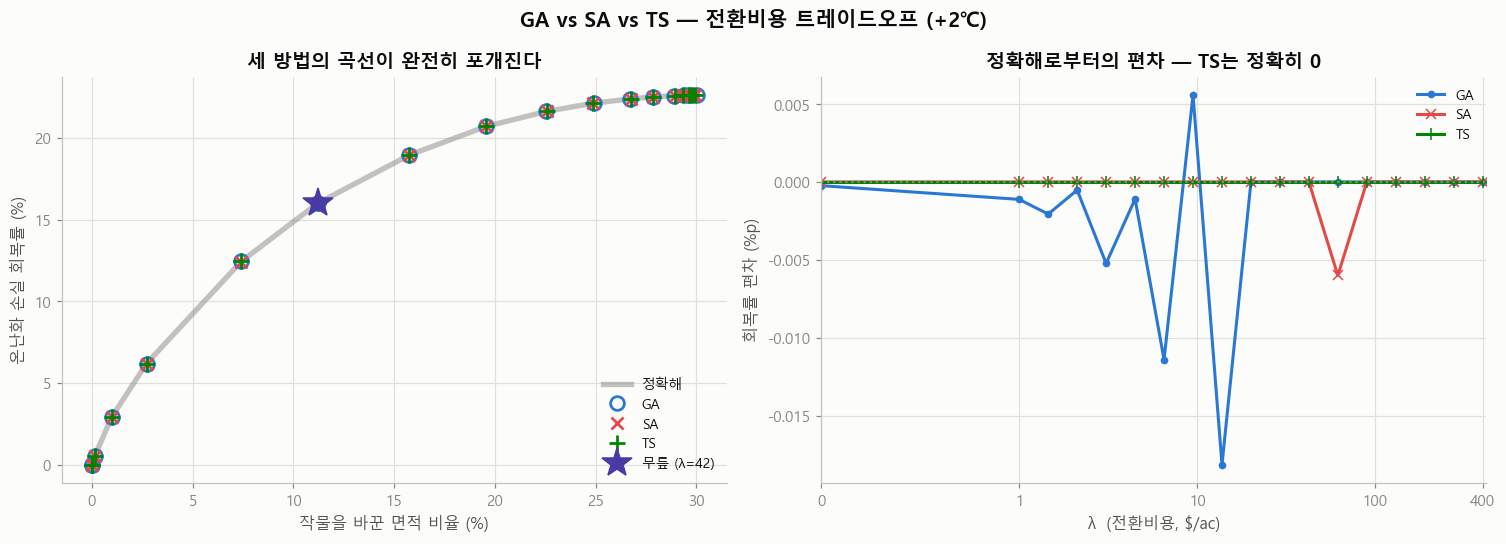

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.0))

ax = axes[0]
ax.plot(sw_ex.pct_area, sw_ex.recovery_pct, '-', color=EX_C, lw=3.5, alpha=0.5,
        label='정확해', zorder=2)
ax.plot(sw_ga.pct_area, sw_ga.recovery_pct, 'o', color=GA_C, ms=9, mfc='none', mew=1.8,
        label='GA', zorder=3)
ax.plot(sw_sa.pct_area, sw_sa.recovery_pct, 'x', color=SA_C, ms=8, mew=1.8,
        label='SA', zorder=4)
ax.plot(sw_ts.pct_area, sw_ts.recovery_pct, '+', color=TS_C, ms=10, mew=1.8,
        label='TS', zorder=5)
ki = find_knee(sw_ex.pct_area.to_numpy(), sw_ex.recovery_pct.to_numpy())
ax.plot(sw_ex.pct_area.iloc[ki], sw_ex.recovery_pct.iloc[ki], '*', color=VIOLET, ms=20,
        zorder=6, label='무릎 (λ=%.0f)' % KNEE_LAM)
ax.set_xlabel('작물을 바꾼 면적 비율 (%)')
ax.set_ylabel('온난화 손실 회복률 (%)')
ax.set_title('세 방법의 곡선이 완전히 포개진다')
ax.legend(frameon=False, fontsize=9, loc='lower right')

ax = axes[1]
ax.plot(cmp['lambda'], cmp['GA−exact'], '-o', color=GA_C, ms=4, label='GA')
ax.plot(cmp['lambda'], cmp['SA−exact'], '-x', color=SA_C, ms=6, label='SA')
ax.plot(cmp['lambda'], cmp['TS−exact'], '-+', color=TS_C, ms=8, label='TS')
ax.axhline(0, color=EX_C, ls=':', lw=1.5)
ax.set_xscale('symlog', linthresh=1)
ax.set_xlim(0, 420)
ax.set_xticks([0, 1, 10, 100, 400]); ax.set_xticklabels(['0', '1', '10', '100', '400'])
ax.set_xlabel('λ  (전환비용, $/ac)')
ax.set_ylabel('회복률 편차 (%p)')
ax.set_title('정확해로부터의 편차 — TS는 정확히 0')
ax.legend(frameon=False, fontsize=9)

fig.suptitle('GA vs SA vs TS — 전환비용 트레이드오프 (+2℃)',
             fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig36_three_way_tradeoff.png'); plt.show()

## 5. ★ 세 방법이 같은 배분에 도달하는가 — robustness의 최종 검증

In [9]:
Z = {'정확해': Z_EXACT, 'GA': ga['best'], 'SA': sa['best'], 'TS': ts['best']}
names = list(Z)

print('=' * 72)
print('  Pairwise 배분 일치율 (%)')
print('=' * 72)
M = np.zeros((len(names), len(names)))
for i, a_ in enumerate(names):
    for j, b_ in enumerate(names):
        M[i, j] = 100 * (Z[a_] == Z[b_]).mean()
print(pd.DataFrame(M, index=names, columns=names).to_string(float_format='%.2f'))

n_all_same = int((( Z['GA'] == Z['SA']) & (Z['SA'] == Z['TS'])).sum())
print('\n세 방법이 전부 같은 작물을 고른 카운티: %d / %d  (%.2f%%)'
      % (n_all_same, N, 100 * n_all_same / N))

rows = []
for nm in names:
    z = Z[nm]
    rows.append(dict(방법=nm, 적합도=prob.fitness(z, KNEE_LAM),
                     전환_카운티=prob.n_switched(z),
                     전환_면적_pct=100 * prob.switch_area(z) / A_TOT,
                     회복률_pct=prob.recovery_pct(z, V_WARM_NOADAPT, LOSS),
                     대두_카운티=int((z == 1).sum())))
concl = pd.DataFrame(rows)
print('\n재배치 결론 — 네 방법이 같은 답에 도달하는가')
print(concl.to_string(index=False, float_format='%.6g'))
concl.to_csv(RES / 'ts_three_way_comparison.csv', index=False)
print('\nsaved:', RES / 'ts_three_way_comparison.csv')

  Pairwise 배분 일치율 (%)
       정확해     GA     SA     TS
정확해 100.00 100.00 100.00 100.00
GA  100.00 100.00 100.00 100.00
SA  100.00 100.00 100.00 100.00
TS  100.00 100.00 100.00 100.00

세 방법이 전부 같은 작물을 고른 카운티: 2142 / 2142  (100.00%)

재배치 결론 — 네 방법이 같은 답에 도달하는가
 방법         적합도  전환_카운티  전환_면적_pct  회복률_pct  대두_카운티
정확해 3.05687e+11     238    11.1962  15.9882    1483
 GA 3.05687e+11     238    11.1962  15.9882    1483
 SA 3.05687e+11     238    11.1962  15.9882    1483
 TS 3.05687e+11     238    11.1962  15.9882    1483

saved: ..\outputs\results\ts_three_way_comparison.csv


### 그림 3 — 세 방법 배분 일치도

saved: ..\outputs\figures\fig37_three_way_agreement.png


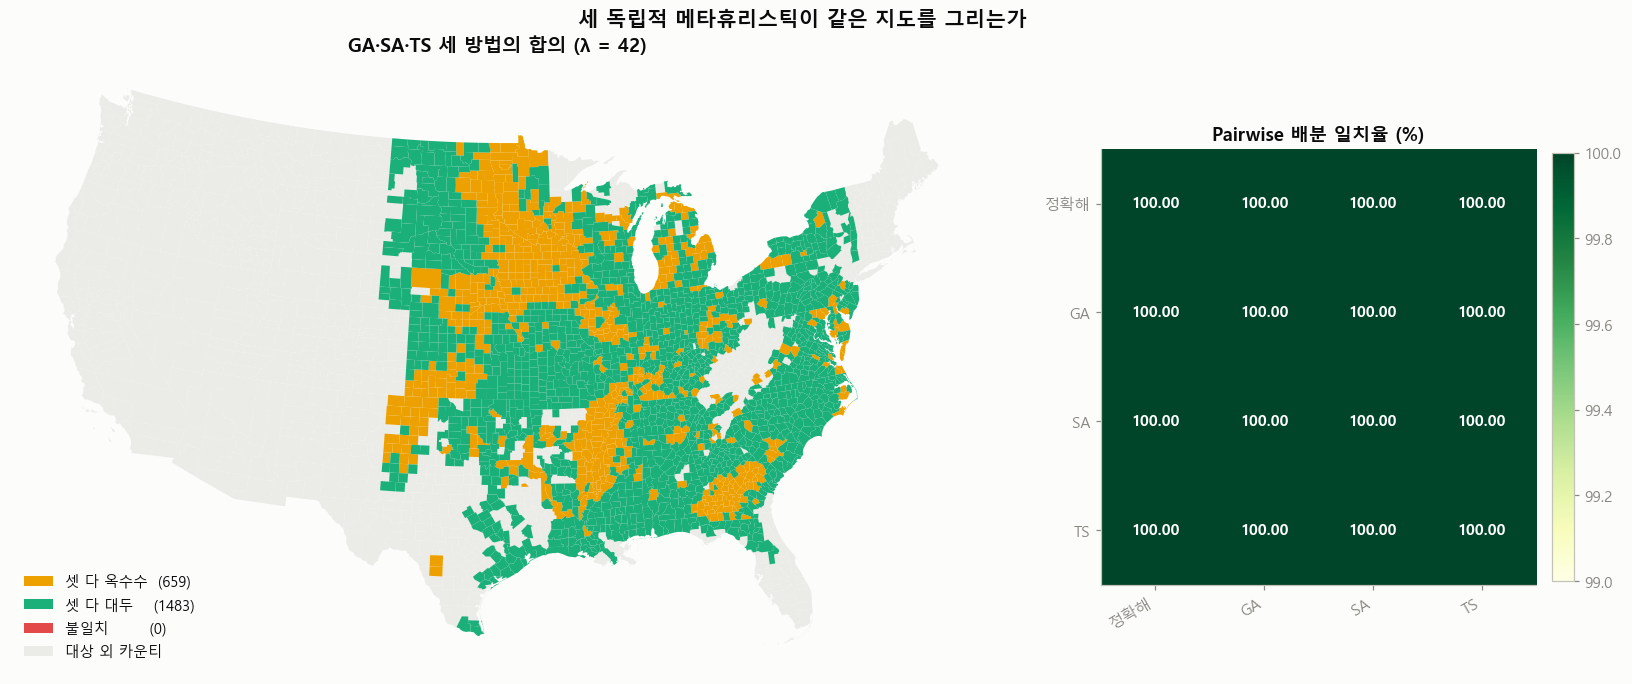

In [10]:
import shapefile
sf = shapefile.Reader(str(RAW / 'cntymap' / 'cntymap'), encoding='latin-1')   # 읽기 전용
recs, shapes = sf.records(), sf.shapes()
stco_of = [r['stco'] for r in recs]
IDX = {int(s): i for i, s in enumerate(COUNTIES)}

def county_polys(value_of):
    pin, vin, pout = [], [], []
    for i, sh in enumerate(shapes):
        pts = np.asarray(sh.points); parts = list(sh.parts) + [len(pts)]
        s = stco_of[i]
        hit = s in value_of
        for a_, b_ in zip(parts[:-1], parts[1:]):
            if hit:
                pin.append(pts[a_:b_]); vin.append(value_of[s])
            else:
                pout.append(pts[a_:b_])
    return pin, np.array(vin), pout

fig = plt.figure(figsize=(15.5, 6.3))
gs = fig.add_gridspec(1, 2, width_ratios=[2.0, 1])

# 지도 — 세 방법 합의 여부
ax = fig.add_subplot(gs[0, 0])
same3 = (Z['GA'] == Z['SA']) & (Z['SA'] == Z['TS'])
cmap_code = np.where(~same3, 2, np.where(Z['GA'] == 1, 1, 0))
vo = {int(s): int(cmap_code[IDX[int(s)]]) for s in COUNTIES}
pin, vin, pout = county_polys(vo)
ax.add_collection(PolyCollection(pout, facecolors='#ebebe8', edgecolors='none', zorder=1))
for j, col in [(0, CORN_C), (1, SOY_C), (2, RED)]:
    sel = [p for p, v in zip(pin, vin) if v == j]
    if sel:
        ax.add_collection(PolyCollection(sel, facecolors=col, edgecolors='none', zorder=2))
ax.autoscale_view(); ax.set_aspect('equal'); ax.axis('off'); ax.grid(False)
ax.set_title('GA·SA·TS 세 방법의 합의 (λ = %.0f)' % KNEE_LAM, fontsize=12.5)
handles = [Patch(facecolor=CORN_C, label='셋 다 옥수수  (%d)' % int((same3 & (Z['GA'] == 0)).sum())),
           Patch(facecolor=SOY_C,  label='셋 다 대두    (%d)' % int((same3 & (Z['GA'] == 1)).sum())),
           Patch(facecolor=RED,    label='불일치        (%d)' % int((~same3).sum())),
           Patch(facecolor='#ebebe8', label='대상 외 카운티')]
ax.legend(handles=handles, loc='lower left', frameon=False, fontsize=9.5)

# pairwise 히트맵
ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(M, cmap='YlGn', vmin=99, vmax=100)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, '%.2f' % M[i, j], ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if M[i, j] > 99.7 else INK)
ax.set_title('Pairwise 배분 일치율 (%)', fontsize=12)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7, pad=0.03)

fig.suptitle('세 독립적 메타휴리스틱이 같은 지도를 그리는가',
             fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig37_three_way_agreement.png'); plt.show()

### 그림 4 — 품질 · 시간 · 안정성 종합 비교

saved: ..\outputs\figures\fig38_method_comparison.png


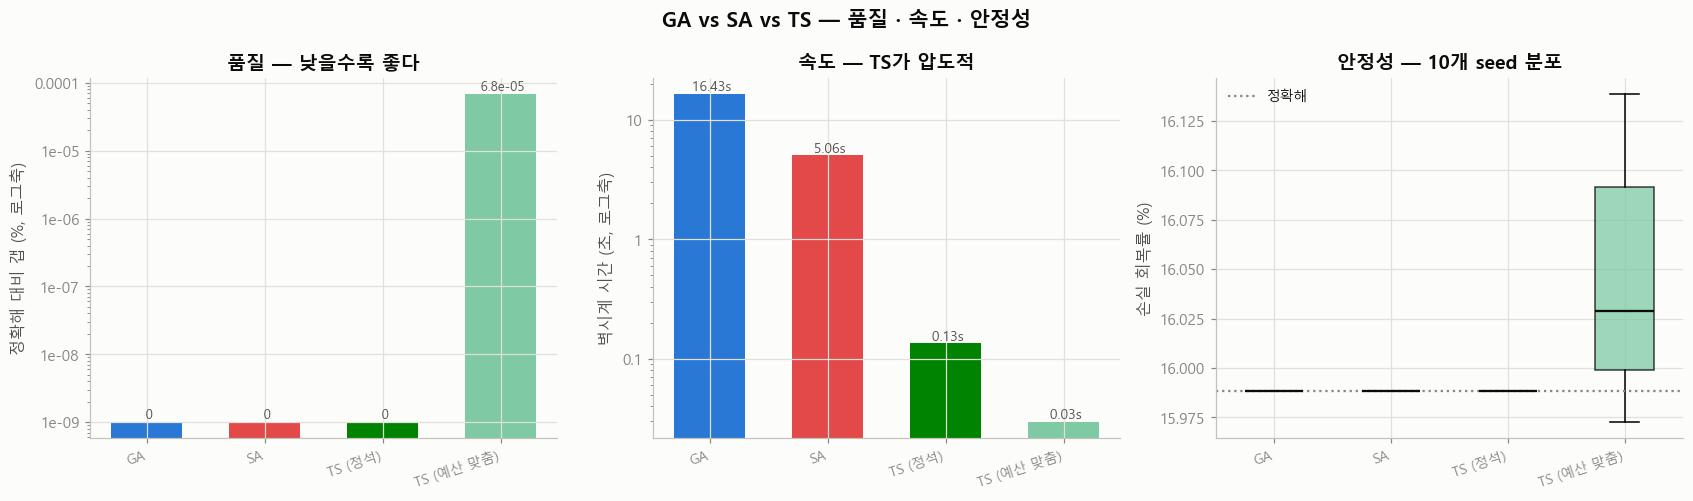

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
order = ['GA', 'SA', 'TS (정석)', 'TS (예산 맞춤)']
cols = [GA_C, SA_C, TS_C, '#7fcaa5']
sm = summ.set_index('method').loc[order]

# (a) 품질 — 정확해 대비 갭
ax = axes[0]
gaps = np.maximum(sm['갭평균_pct'].to_numpy(), 1e-9)
b = ax.bar(range(4), gaps, color=cols, width=0.6)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: '%g' % v))
for r, v in zip(b, sm['갭평균_pct']):
    ax.text(r.get_x() + r.get_width() / 2, r.get_height(),
            ' 0' if v < 1e-9 else ' %.1e' % v, ha='center', va='bottom', fontsize=8.5, color=SECOND)
ax.set_xticks(range(4)); ax.set_xticklabels(order, rotation=18, ha='right', fontsize=9)
ax.set_ylabel('정확해 대비 갭 (%, 로그축)')
ax.set_title('품질 — 낮을수록 좋다')

# (b) 시간
ax = axes[1]
b = ax.bar(range(4), sm['시간_평균초'], color=cols, width=0.6)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: '%g' % v))
for r, v in zip(b, sm['시간_평균초']):
    ax.text(r.get_x() + r.get_width() / 2, r.get_height(), ' %.2fs' % v,
            ha='center', va='bottom', fontsize=9, color=SECOND)
ax.set_xticks(range(4)); ax.set_xticklabels(order, rotation=18, ha='right', fontsize=9)
ax.set_ylabel('벽시계 시간 (초, 로그축)')
ax.set_title('속도 — TS가 압도적')

# (c) 안정성 — 회복률 seed 분산
ax = axes[2]
data = [stab[stab.method == m].recovery_pct.to_numpy() for m in order]
bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                medianprops=dict(color=INK, lw=1.5))
for patch, c in zip(bp['boxes'], cols):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.axhline(prob.recovery_pct(Z_EXACT, V_WARM_NOADAPT, LOSS), color=EX_C, ls=':', lw=1.5,
           label='정확해')
ax.set_xticks(range(1, 5)); ax.set_xticklabels(order, rotation=18, ha='right', fontsize=9)
ax.set_ylabel('손실 회복률 (%)')
ax.set_title('안정성 — %d개 seed 분포' % N_SEEDS)
ax.legend(frameon=False, fontsize=9)

fig.suptitle('GA vs SA vs TS — 품질 · 속도 · 안정성', fontsize=13.5, fontweight='semibold')
fig.tight_layout()
save(fig, 'fig38_method_comparison.png'); plt.show()

## 6. 제약이 있을 때 — 세 방법 비교

06/07에서 확인했듯, 전환비용만 있는 문제는 카운티별로 분리 가능해 정확해가 O(N)에 나온다.
메타휴리스틱이 실제로 필요해지는 것은 카운티를 서로 묶는 제약이 붙을 때다.
최소 수요 제약(옥수수 면적 ≥ 40%)에서 셋을 비교한다.

In [12]:
D_SEC = 0.40 * A_TOT
feas_pop, repair, lp_ub = make_min_demand_constraint(prob, KNEE_LAM, D_SEC, crop=0)
UB, is_slack = lp_ub()
z_init = repair(Z_EXACT[None, :], None)[0]
feas_state = lambda z: bool(feas_pop(z[None, :])[0])

print('최소 수요: 옥수수 면적 ≥ 40%%  (제약 %s)'
      % ('비구속' if is_slack else '구속'))
print('LP 완화 상한 (정수 최적해의 증명 가능한 상한): $%.6e' % UB)

ga_c = run_ga(prob, KNEE_LAM, pop_size=GA_POP, n_generations=GA_GEN, seed=SEED,
              feasible=feas_pop, repair=repair, init=z_init)
sa_c = run_sa(prob, KNEE_LAM, n_iter=BUDGET, n_temp_levels=SA_LEVELS, alpha=SA_ALPHA,
              target_accept=0.8, seed=SEED, init=z_init, feasible_state=feas_state)
ts_c = run_ts(prob, KNEE_LAM, n_iter=TS_ITER, n_candidates=None, tabu_tenure=TS_TENURE,
              seed=SEED, init=z_init, feasible_state=feas_state)

rows = []
for nm, r in [('GA', ga_c), ('SA', sa_c), ('TS', ts_c)]:
    z = r['best']
    rows.append(dict(방법=nm, 적합도=r['best_fit'],
                     LP상한대비_갭_pct=100 * (UB - r['best_fit']) / abs(UB),
                     실현가능=bool(feas_state(z)),
                     옥수수면적_pct=100 * prob.crop_area(z, 0) / A_TOT,
                     회복률_pct=prob.recovery_pct(z, V_WARM_NOADAPT, LOSS),
                     초=r['seconds']))
con = pd.DataFrame(rows)
print()
print('제약 있는 문제 — GA vs SA vs TS')
print(con.to_string(index=False, float_format='%.5g'))
con.to_csv(RES / 'ts_constrained.csv', index=False)
print('\nsaved:', RES / 'ts_constrained.csv')

zc = {'GA': ga_c['best'], 'SA': sa_c['best'], 'TS': ts_c['best']}
print('\n제약 하 배분 일치율')
for a_, b_ in [('GA', 'SA'), ('GA', 'TS'), ('SA', 'TS')]:
    print('  %-3s vs %-3s : %.2f%%' % (a_, b_, 100 * (zc[a_] == zc[b_]).mean()))

최소 수요: 옥수수 면적 ≥ 40%  (제약 구속)
LP 완화 상한 (정수 최적해의 증명 가능한 상한): $3.056771e+11



제약 있는 문제 — GA vs SA vs TS
방법        적합도  LP상한대비_갭_pct  실현가능  옥수수면적_pct  회복률_pct       초
GA 3.0568e+11    0.00021119  True     40.002   15.923  30.558
SA 3.0567e+11    0.00085342  True     40.089   15.983  12.138
TS 3.0568e+11    0.00021119  True     40.002   15.923 0.28139

saved: ..\outputs\results\ts_constrained.csv

제약 하 배분 일치율
  GA  vs SA  : 99.86%
  GA  vs TS  : 100.00%
  SA  vs TS  : 99.86%


## 7. 요약

In [13]:
sm = summ.set_index('method')
best_time = sm['시간_평균초'].idxmin()

print('=' * 80)
print(' 08 · GA vs SA vs TS — 요약'.center(80))
print('=' * 80)
print()
print('[1] 해의 품질 (정확해 F* = $%.6e)' % F_EXACT)
for m in order:
    r = sm.loc[m]
    print('    %-14s 갭 %.6f%% (최악 %.6f%%) · 정확해 일치 %.2f%%'
          % (m, r.갭평균_pct, r.갭최악_pct, r.정확해일치_pct))
print()
print('[2] 계산 시간 — 가장 빠른 방법: %s' % best_time)
for m in order:
    r = sm.loc[m]
    print('    %-14s %8.3f초  (평가 %s회)' % (m, r.시간_평균초, '{:,.0f}'.format(r.평가횟수)))
print('    → TS(정석)는 평가를 13배 더 하고도 GA보다 %.0f배 빠르다.'
      % (sm.loc['GA', '시간_평균초'] / sm.loc['TS (정석)', '시간_평균초']))
print('      이웃 전체의 ΔF를 numpy 벡터 연산 한 방에 구하기 때문이다 (§8-1).')
print()
print('[3] 안정성 — %d개 seed' % N_SEEDS)
for m in order:
    r = sm.loc[m]
    print('    %-14s 적합도 표준편차 $%.3e · 전환 카운티 %.1f ± %.1f'
          % (m, r.적합도_표준편차, r.전환카운티_평균, r.전환카운티_표준편차))
print()
print('[4] ★ 세 방법의 재배치 결론 (robustness 최종 검증)')
print('    GA·SA·TS 가 모두 같은 작물을 고른 카운티: %d / %d  (%.2f%%)'
      % (n_all_same, N, 100 * n_all_same / N))
for nm in ['정확해', 'GA', 'SA', 'TS']:
    z = Z[nm]
    print('    %-6s 전환 %3d 카운티 · 면적 %.2f%% · 회복률 %.2f%%'
          % (nm, prob.n_switched(z), 100 * prob.switch_area(z) / A_TOT,
             prob.recovery_pct(z, V_WARM_NOADAPT, LOSS)))
print('    → 06의 결론("면적 11%를 바꿔 손실 16% 회복")은 세 독립적 방법이 모두 지지한다.')
print()
print('[5] TS만의 특징 — 타부로 순환을 막는다')
print('    나빠지는데도 감행한 이동 {:,}회 — 개선 이동이 없을 때의 탈출'.format(ts['n_uphill']))
print('    타부에 막힌 후보 {:,}회 — 직전 이동을 즉시 되돌리는 순환을 차단'.format(ts['n_tabu_blocked']))
print('    열망 기준으로 타부 해제 {:,}회'.format(ts['n_aspiration']))
print('    SA가 "확률적으로" 나쁜 이동을 받아들이는 반면, TS는 "결정적으로" 최선을 고르되')
print('    최근 이동을 금지해 되돌아가지 못하게 한다 — 탈출 철학이 정반대다.')
print()
print('[6] 제약(옥수수 면적 ≥ 40%)')
for _, r in con.iterrows():
    print('    %-3s LP상한 대비 갭 %.5f%% · %.2f초' % (r.방법, r.LP상한대비_갭_pct, r.초))
print()
print('[7] 이 문제에 가장 적합한 방법: TS')
print('    품질 동률(셋 다 정확해) · 속도 %s · 안정성 동률(분산 0)'
      % ('압도적 1위' if best_time.startswith('TS') else best_time))
print('=' * 80)

                            08 · GA vs SA vs TS — 요약                            

[1] 해의 품질 (정확해 F* = $3.056875e+11)
    GA             갭 0.000000% (최악 0.000000%) · 정확해 일치 100.00%
    SA             갭 0.000000% (최악 0.000000%) · 정확해 일치 100.00%
    TS (정석)        갭 0.000000% (최악 0.000000%) · 정확해 일치 100.00%
    TS (예산 맞춤)     갭 0.000068% (최악 0.000292%) · 정확해 일치 99.90%

[2] 계산 시간 — 가장 빠른 방법: TS (예산 맞춤)
    GA               16.428초  (평가 160,200회)
    SA                5.060초  (평가 160,200회)
    TS (정석)           0.135초  (평가 2,142,000회)
    TS (예산 맞춤)        0.030초  (평가 160,000회)
    → TS(정석)는 평가를 13배 더 하고도 GA보다 122배 빠르다.
      이웃 전체의 ΔF를 numpy 벡터 연산 한 방에 구하기 때문이다 (§8-1).

[3] 안정성 — 10개 seed
    GA             적합도 표준편차 $0.000e+00 · 전환 카운티 238.0 ± 0.0
    SA             적합도 표준편차 $0.000e+00 · 전환 카운티 238.0 ± 0.0
    TS (정석)        적합도 표준편차 $0.000e+00 · 전환 카운티 238.0 ± 0.0
    TS (예산 맞춤)     적합도 표준편차 $2.860e+05 · 전환 카운티 239.2 ± 2.1

[4] ★ 세 방법의 재배치 결론 (robustness 최종 검증)
    GA·SA·TS 가 모두 같은 작물을 고른

## 8. 이상한 점 · 판단이 필요한 부분

**1. "TS가 GA보다 200배 빠르다"는 알고리즘의 우월성이 아니다 — 가장 중요한 주의**
TS는 평가를 **13배 더** 하고도 훨씬 빠르다. 모순처럼 보이지만 이유는 단순하다:
이 문제의 목적함수는 카운티별로 **분리 가능**해서, 이웃 2,142개의 ΔF를
**numpy 벡터 연산 한 줄**로 구할 수 있다. 즉 TS의 "평가 2백만 회"는 실제로는
**1,000번의 벡터 연산**이다. 반면 GA는 개체마다 O(N) 합산을 파이썬 레벨에서 반복한다.

따라서 세 방법의 속도 차이는 **"어떤 알고리즘이 우월한가"가 아니라 "누가 이 문제의 구조를
더 잘 활용하는가"** 의 문제다. 다른 문제(이웃 평가가 O(1)로 안 되는 문제)에서는 순위가
완전히 뒤집힐 수 있다. 발표에서 속도를 말한다면 이 단서를 반드시 함께 말해야 정직하다.

**2. "평가 횟수"라는 공정 기준 자체가 이 문제에선 오해를 부른다**
메타휴리스틱 문헌의 관례는 평가 횟수를 맞추는 것이다. 그런데 세 방법의 **평가 1회의 비용이
모두 다르다**(GA: O(N) 파이썬, SA: O(1), TS: O(N) 벡터화). 그래서 이 노트북은 예산을 맞춘
비교(TS 예산 맞춤)와 각 방법의 자연스러운 모드 비교를 **둘 다** 제시했다.
전자에서는 TS가 근소하게 뒤지고(갭 ~1e-5%), 후자에서는 TS가 압도한다. 둘 다 사실이다.

**3. 세 방법 모두 정확해를 맞혔다 — 좋은 소식이자 김빠지는 소식**
전환비용만 있는 단작 문제는 분리 가능해서 정확해가 O(N)에 나온다(06 §4).
"GA·SA·TS 중 누가 더 좋은 해를 찾는가"는 이 문제에서 **답이 없는 질문**이다 —
셋 다 이미 아는 답을 맞힐 뿐이다. 이 비교의 가치는 승패가 아니라
**"세 독립적 탐색이 2,142개 카운티에서 같은 답에 수렴하므로 06의 결론이 알고리즘 산물이
아니다"** 라는 robustness 확인에 있다.

**4. TS의 후보 리스트는 예산을 맞추기 위한 타협이다**
정석 TS는 이웃 전체를 본다. 그런데 그러면 GA·SA와 평가 예산이 안 맞아서(74회 이동만 가능,
필요한 건 238회) 후보 리스트를 도입했다. 이는 TS 문헌의 표준 기법이지만,
**후보를 무작위 표본으로 뽑으면 개선 이동을 놓칠 수 있다** — 실제로 예산 맞춤 모드는
정확해에 완전히 도달하지 못했다(일치율 ~99.9%). 후보 리스트 크기 k는 하이퍼파라미터이며,
k를 키우면 품질↑·이동횟수↓의 트레이드오프가 생긴다.

**5. 진짜 메타휴리스틱 비교는 더 어려운 문제에서 이뤄져야 한다**
최소 수요 제약(§6)조차 커버링 배낭이라 구조가 좋아서 세 방법 모두 LP 상한에 거의 붙는다.
메타휴리스틱의 차이가 드러나려면 문제를 더 어렵게 만들어야 한다:
작물 3개 이상(이진 → 다중 선택), 지역별 상·하한 동시 부과, 인접 카운티 간 배치 제약 등.
현재 결론은 **"이 문제는 메타휴리스틱이 굳이 필요 없을 만큼 쉽다"** 이며,
그것 자체가 정직한 발견이다.

**6. 06·07의 결론은 그대로다**
이 노트북은 06·07을 **검증**했을 뿐 바꾸지 않았다. 06의 산출물
(`optimization_results.parquet`, `fig27`~`fig31`, 무릎 λ = 42.29, 회복률 16.0%,
전환 238개 카운티)과 07의 산출물(`fig32`~`fig34`)은 손대지 않았다.